# 14 - Leakage-controlled 3-fold CV (Option B): a robustness check, not a re-optimisation

**What this notebook is NOT for.** This is not an attempt to improve MiniConvNet's reported
accuracy. Based on evidence already gathered in this project (a less-aggressive, duplicate-only
split previously showed no meaningful accuracy change), the expected, most likely outcome is that
this result lands close to the existing **70.59% +/- 12.00%** headline, possibly slightly lower -
not higher. **The actual purpose is to confirm, or honestly revise, confidence in that existing
headline number**, by re-running the identical 3-fold CV methodology on Phase 1's
leakage-controlled split instead of the plain pooled split the original headline used.

**Whatever this comes back as gets reported as-is.** A confirmed-lower, leakage-controlled number is
a *more honest* number, not a failure - see Step 5.

## The one thing that is allowed to differ, and why

Phase 0's own audit of this project flagged a real methodological risk: the original CV
(`notebooks/03_cross_validation.ipynb`) pools all 1,000 images and partitions them with plain
`StratifiedKFold`, which has no awareness of duplicate or near-duplicate images. A fold's "test"
portion can therefore share an image - or a near-identical one - with that same fold's training
portion, inflating the reported accuracy for reasons that have nothing to do with genuine
generalisation.

Phase 1 already built and verified a **leakage-controlled split**
(`outputs/leakage/split_assignments.csv`) with an `image_group` column: every exact-duplicate and
near-duplicate image is collapsed into one group, and Phase 1 already proved (by construction and by
assertion) that no group straddles its train/val/test boundary. This notebook:

1. loads that **exact, already-built** split - it does not construct a new one;
2. pools it (same as the original notebook pools `faithful`) and partitions it into 3 folds using
   **`StratifiedGroupKFold(groups=image_group)`** instead of plain `StratifiedKFold` - this is the
   ONE change from the original methodology, and it is verified empirically below (not just argued)
   that it actually prevents any `image_group` from straddling a fold's train/test boundary, and that
   a naive `StratifiedKFold` on the exact same data would NOT have prevented it;
3. trains MiniConvNet with the **identical** architecture and training configuration as the original
   headline run - LeakyReLU, He initialisation, the extra-pooling bottleneck fix, `Adam(1e-4,
   clipnorm=1.0)`, label smoothing 0.05, `ReduceLROnPlateau`, early-stopping patience 12, seed 42.
   Nothing about the model or its training is touched.

The inner 15%-of-training-pool validation split used for early stopping *within* each outer fold is
left exactly as in the original methodology (plain stratified split, no group constraint) - this
notebook only makes the **outer** fold boundary (what defines "test" vs "train" for a fold) group-
aware, which is the boundary that actually determines the reported test accuracy. Going further and
group-constraining the inner split too would be a legitimate stricter version, but it is not what
"only the split differs" calls for here - noted as a limitation, not silently done.

**No new checkpoints, no retraining beyond these 3 folds, no changes to `outputs/results_table.csv`
or any other existing file.** Output goes only to
`outputs/leakage/leakage_controlled_cv_results.csv` and `.json`.

**Nothing in this notebook has been executed.** It was written, not run.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.config import *
from src.data_utils import resolve_data_root

ensure_dirs()
print('data root:', resolve_data_root())
print('folds:', CV_FOLDS, '| epochs per fold:', EPOCHS_CV, '(identical to notebooks/03)')

data root: C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\Data
folds: 3 | epochs per fold: 40 (identical to notebooks/03)


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split

from src.data_utils import make_dataset
from src.models import build_miniconvnet, count_params
from src.train_utils import (set_global_seeds, compute_report, compile_model, make_callbacks,
                             make_epoch_timer, save_history, final_epoch_summary, run_name_for,
                             estimate_training_time)
from src.evaluate_utils import (predict, compute_metrics, detect_collapse, print_collapse_report,
                                confusion, summarize_cv, format_mean_std, tumor_vs_subtype_breakdown,
                                interpret_breakdown, save_predictions, plot_confusion_matrix)

from src.leakage_cv_utils import (
    SPLIT_ASSIGNMENTS_CSV, LEAKAGE_CONTROLLED_CV_RESULTS_CSV, LEAKAGE_CONTROLLED_CV_RESULTS_JSON,
    load_leakage_controlled_split, assert_no_group_leakage_in_folds,
    load_headline_reference, compare_to_headline, write_leakage_controlled_cv_results,
)

set_global_seeds(SEED)
for k, v in compute_report().items():
    print(f'{k}: {v}')

tensorflow: 2.16.2
num_gpus: 0
gpus: []
num_cpu_devices: 1
os_cpu_count: 16
note: CPU-only as planned - keep the scoped budgets.


## STEP 1 - load and verify the EXISTING leakage-controlled split

**This does not construct a new split.** `load_leakage_controlled_split()` looks for exactly
`outputs/leakage/split_assignments.csv` (written by `notebooks/08_leakage_analysis.ipynb`), checks
every required column is present, checks its `split_variant` tag is exactly
`leakage_controlled_image_group`, and rebases its stored filepaths onto this machine's data root.

**If any of that fails, this notebook stops here and reports why** - it does not fall back to
building a fresh split as a substitute, per the task's explicit instruction.

In [3]:
load_result = load_leakage_controlled_split()

SPLIT_LOADED_OK = load_result['ok']
if not SPLIT_LOADED_OK:
    print('=' * 78)
    print('STOP - the leakage-controlled split could not be loaded.')
    print('=' * 78)
    print(load_result['reason'])
    print()
    print('This notebook does NOT construct a substitute split. Resolve the issue above')
    print('(most likely: run notebooks/08_leakage_analysis.ipynb, or restore ./Data/) and')
    print('re-run this cell before continuing.')
else:
    pool = load_result['df']
    print(f"loaded: {load_result['path']}")
    print(f'pooled images: {len(pool)}')
    print(pool['class'].value_counts().reindex(CLASS_NAMES).to_string())
    print()
    print('image groups in this pool:', pool['image_group'].nunique(),
          '(exact + near-duplicate images collapsed into one group each - see notebook 08)')

loaded: C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\outputs\leakage\split_assignments.csv
pooled images: 1000
class
adenocarcinoma             338
large.cell.carcinoma       187
normal                     215
squamous.cell.carcinoma    260

image groups in this pool: 726 (exact + near-duplicate images collapsed into one group each - see notebook 08)


## STEP 2 - fold construction: `StratifiedGroupKFold(groups=image_group)`

**The one deliberate change from the original methodology.** Verified below, not just argued:
`StratifiedGroupKFold` on this pool produces zero `image_group` violations across all folds, while a
plain `StratifiedKFold` on the exact same data does not - proving the group-aware fold construction
is actually doing something, not a cosmetic substitution.

In [4]:
if SPLIT_LOADED_OK:
    sgkf = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    folds = list(sgkf.split(pool.index.values, pool['label'].values,
                            groups=pool['image_group'].values))

    for i, (tr_idx, te_idx) in enumerate(folds, start=1):
        te_counts = pool.iloc[te_idx]['class'].value_counts().reindex(CLASS_NAMES).to_dict()
        print(f'fold {i}: train={len(tr_idx):4d} test={len(te_idx):4d} test class counts={te_counts}')

fold 1: train= 667 test= 333 test class counts={'adenocarcinoma': 113, 'large.cell.carcinoma': 62, 'normal': 71, 'squamous.cell.carcinoma': 87}
fold 2: train= 666 test= 334 test class counts={'adenocarcinoma': 113, 'large.cell.carcinoma': 62, 'normal': 72, 'squamous.cell.carcinoma': 87}
fold 3: train= 667 test= 333 test class counts={'adenocarcinoma': 112, 'large.cell.carcinoma': 63, 'normal': 72, 'squamous.cell.carcinoma': 86}


In [5]:
if SPLIT_LOADED_OK:
    group_check = assert_no_group_leakage_in_folds(pool, folds)
    print('StratifiedGroupKFold group-leakage check:', group_check)
    assert group_check['clean'], (
        'image_group violations found in the group-aware folds - this would mean the leakage '
        'control failed for this specific run; investigate before proceeding, do not report '
        'results from a leaky CV.')
    print('CONFIRMED: no image_group straddles any fold\'s train/test boundary.')

    # Contrast check, informational only - proves the fix matters, does not affect the folds used.
    naive_skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    naive_folds = list(naive_skf.split(pool.index.values, pool['label'].values))
    naive_check = assert_no_group_leakage_in_folds(pool, naive_folds)
    print(f"\nFor contrast: a NAIVE plain StratifiedKFold on this SAME pool would have produced "
          f"{sum(v['n_overlapping_groups'] for v in naive_check['violations'])} "
          f"cross-fold image_group violations across {len(naive_check['violations'])} fold(s) - "
          'this is why the group-aware split matters, and these naive folds are NOT used below.')

StratifiedGroupKFold group-leakage check: {'clean': True, 'violations': [], 'n_folds_checked': 3}
CONFIRMED: no image_group straddles any fold's train/test boundary.

For contrast: a NAIVE plain StratifiedKFold on this SAME pool would have produced 163 cross-fold image_group violations across 3 fold(s) - this is why the group-aware split matters, and these naive folds are NOT used below.


## Run helper - identical training configuration to `notebooks/03_cross_validation.ipynb`

Compare this cell line-by-line against the original if in doubt: `build_miniconvnet()`,
`compile_model()`, `EPOCHS_CV`, `make_callbacks()`, `detect_collapse()` are all called exactly the
same way. The only differences are the run-name tag (`'leakage_controlled'` instead of `'faithful'`,
so these predictions/history files never collide with or overwrite the originals) and, obviously,
which `pool` the fold indices are drawn from.

In [6]:
def run_fold(fold_idx, tr_idx, te_idx, verbose=2):
    set_global_seeds(SEED + fold_idx)   # identical to notebooks/03 - different init per fold, reproducible
    run_name = run_name_for('cv', 'leakage_controlled', f'fold{fold_idx}')

    train_pool = pool.iloc[tr_idx].reset_index(drop=True)
    test_df = pool.iloc[te_idx].reset_index(drop=True)
    # Inner train/val split for early stopping: left EXACTLY as the original methodology
    # (plain stratified split, no group constraint) - see the markdown note above.
    tr_df, val_df = train_test_split(train_pool, test_size=0.15,
                                     stratify=train_pool['class'],
                                     random_state=SEED + fold_idx)

    # one_hot=True because the model trains with label smoothing - identical to notebooks/03.
    train_ds = make_dataset(tr_df, shuffle=True, augment=True, seed=SEED + fold_idx, one_hot=True)
    val_ds = make_dataset(val_df, one_hot=True)
    test_ds = make_dataset(test_df, one_hot=True)

    model = compile_model(build_miniconvnet(), verbose=False)
    timer = make_epoch_timer(verbose=0)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CV,
                        callbacks=make_callbacks(run_name, timer=timer, checkpoint=False,
                                                 verbose=0),
                        verbose=verbose)
    save_history(history, run_name, timer=timer)
    summary = final_epoch_summary(history, timer=timer)

    y_true, y_pred, y_prob = predict(model, test_ds)
    metrics = compute_metrics(y_true, y_pred, y_prob)

    save_predictions(run_name, y_true, y_pred, y_prob,
                     meta={'split_variant': 'leakage_controlled_image_group', 'fold': fold_idx,
                           'activation': ACTIVATION, 'label_smoothing': LABEL_SMOOTHING,
                           'purpose': 'Option B robustness check - not the headline run'})

    collapse = detect_collapse(history=history, kappa=metrics['cohen_kappa'],
                               mcc=metrics['mcc'], y_pred=y_pred)
    breakdown = tumor_vs_subtype_breakdown(y_true, y_pred)
    n_classes = collapse['details'].get('n_predicted_classes')

    print(f"\nfold {fold_idx} -> acc={metrics['accuracy']:.4f} f1={metrics['f1_macro']:.4f} "
          f"kappa={metrics['cohen_kappa']:.4f} classes={n_classes}/{NUM_CLASSES} "
          f"epochs={summary['epochs_trained']} "
          f"time={summary.get('total_minutes')}min status={collapse['status']}")
    if collapse['collapsed']:
        print_collapse_report(collapse, run_name)
        print('confusion matrix:')
        print(confusion(y_true, y_pred))

    tf.keras.backend.clear_session()
    return {'fold': fold_idx, 'run_name': run_name, 'status': collapse['status'],
            'n_predicted_classes': n_classes,
            'epochs_trained': summary['epochs_trained'],
            'minutes': summary.get('total_minutes'),
            'binary_tumor_acc': breakdown['binary_tumor_vs_healthy_accuracy'],
            'subtype_acc': breakdown['subtype_accuracy_all_tumors'],
            'y_true': y_true, 'y_pred': y_pred, **metrics}

## Time estimate before committing to all 3 folds

Same measured-then-print pattern as every training notebook in this project.

In [7]:
if SPLIT_LOADED_OK:
    _probe_tr = make_dataset(pool.iloc[folds[0][0]].reset_index(drop=True),
                             shuffle=True, augment=True, seed=SEED, one_hot=True)
    _probe_va = make_dataset(pool.iloc[folds[0][1]].reset_index(drop=True), one_hot=True)

    est = estimate_training_time(
        model_fn=lambda: compile_model(build_miniconvnet(), verbose=False),
        train_ds=_probe_tr, val_ds=_probe_va,
        planned_epochs=EPOCHS_CV, n_runs=CV_FOLDS)

    del _probe_tr, _probe_va

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



TIME ESTIMATE (measured, not guessed)
--------------------------------------
  measured        : 8.2s/epoch over 1 real epoch(s)
  planned         : 40 epochs x 3 run(s) = 120 epochs (upper bound)
  projected       : ~16.5 min (~0.27 h)
  early stopping usually ends runs sooner, so treat this as a ceiling.

  Under the 20-minute threshold - safe to proceed.


## STEP 2 (cont.) - run the 3 folds

In [8]:
if SPLIT_LOADED_OK:
    cv_results = [run_fold(i, tr, te) for i, (tr, te) in enumerate(folds, start=1)]
    print('\nfolds complete:', len(cv_results))
    print('total wall clock:', round(sum(f['minutes'] or 0 for f in cv_results), 1), 'min')

Epoch 1/40


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


18/18 - 7s - 371ms/step - accuracy: 0.3180 - loss: 1.4858 - val_accuracy: 0.3465 - val_loss: 1.3290 - learning_rate: 1.0000e-04 - epoch_seconds: 6.6711
Epoch 2/40
18/18 - 4s - 198ms/step - accuracy: 0.3604 - loss: 1.3227 - val_accuracy: 0.4851 - val_loss: 1.2709 - learning_rate: 1.0000e-04 - epoch_seconds: 3.5667
Epoch 3/40
18/18 - 4s - 196ms/step - accuracy: 0.3993 - loss: 1.2868 - val_accuracy: 0.5050 - val_loss: 1.2198 - learning_rate: 1.0000e-04 - epoch_seconds: 3.5250
Epoch 4/40
18/18 - 4s - 199ms/step - accuracy: 0.3869 - loss: 1.2635 - val_accuracy: 0.4653 - val_loss: 1.1747 - learning_rate: 1.0000e-04 - epoch_seconds: 3.5760
Epoch 5/40
18/18 - 4s - 207ms/step - accuracy: 0.4081 - loss: 1.2522 - val_accuracy: 0.5149 - val_loss: 1.1411 - learning_rate: 1.0000e-04 - epoch_seconds: 3.7204
Epoch 6/40
18/18 - 5s - 283ms/step - accuracy: 0.4594 - loss: 1.2152 - val_accuracy: 0.4257 - val_loss: 1.1605 - learning_rate: 1.0000e-04 - epoch_seconds: 5.0864
Epoch 7/40
18/18 - 5s - 289ms/ste

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


18/18 - 12s - 675ms/step - accuracy: 0.2933 - loss: 1.4642 - val_accuracy: 0.4900 - val_loss: 1.2380 - learning_rate: 1.0000e-04 - epoch_seconds: 12.1448
Epoch 2/40
18/18 - 7s - 386ms/step - accuracy: 0.4223 - loss: 1.2572 - val_accuracy: 0.4900 - val_loss: 1.1792 - learning_rate: 1.0000e-04 - epoch_seconds: 6.9398
Epoch 3/40
18/18 - 5s - 287ms/step - accuracy: 0.4523 - loss: 1.2052 - val_accuracy: 0.4900 - val_loss: 1.1401 - learning_rate: 1.0000e-04 - epoch_seconds: 5.1607
Epoch 4/40
18/18 - 5s - 296ms/step - accuracy: 0.4929 - loss: 1.1614 - val_accuracy: 0.5700 - val_loss: 1.1103 - learning_rate: 1.0000e-04 - epoch_seconds: 5.3300
Epoch 5/40
18/18 - 7s - 366ms/step - accuracy: 0.4753 - loss: 1.1547 - val_accuracy: 0.5100 - val_loss: 1.0940 - learning_rate: 1.0000e-04 - epoch_seconds: 6.5961
Epoch 6/40
18/18 - 6s - 324ms/step - accuracy: 0.5071 - loss: 1.1186 - val_accuracy: 0.5000 - val_loss: 1.0908 - learning_rate: 1.0000e-04 - epoch_seconds: 5.8306
Epoch 7/40
18/18 - 6s - 332ms/s

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


18/18 - 9s - 524ms/step - accuracy: 0.3127 - loss: 1.4639 - val_accuracy: 0.4653 - val_loss: 1.2595 - learning_rate: 1.0000e-04 - epoch_seconds: 9.4386
Epoch 2/40
18/18 - 5s - 283ms/step - accuracy: 0.3763 - loss: 1.2854 - val_accuracy: 0.4455 - val_loss: 1.1801 - learning_rate: 1.0000e-04 - epoch_seconds: 5.0970
Epoch 3/40
18/18 - 3s - 194ms/step - accuracy: 0.4276 - loss: 1.2246 - val_accuracy: 0.5050 - val_loss: 1.1615 - learning_rate: 1.0000e-04 - epoch_seconds: 3.4831
Epoch 4/40
18/18 - 3s - 192ms/step - accuracy: 0.4329 - loss: 1.2185 - val_accuracy: 0.4752 - val_loss: 1.1663 - learning_rate: 1.0000e-04 - epoch_seconds: 3.4581
Epoch 5/40
18/18 - 4s - 202ms/step - accuracy: 0.4470 - loss: 1.2015 - val_accuracy: 0.4653 - val_loss: 1.1035 - learning_rate: 1.0000e-04 - epoch_seconds: 3.6289
Epoch 6/40
18/18 - 4s - 249ms/step - accuracy: 0.4576 - loss: 1.1816 - val_accuracy: 0.5644 - val_loss: 1.0754 - learning_rate: 1.0000e-04 - epoch_seconds: 4.4898
Epoch 7/40
18/18 - 7s - 400ms/ste

## STEP 3 - per-fold metrics table, and collapse exclusion (identical convention to notebooks/03)

In [9]:
if SPLIT_LOADED_OK:
    cols = ['fold', 'accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'cohen_kappa', 'mcc',
            'binary_tumor_acc', 'subtype_acc', 'n_predicted_classes', 'epochs_trained', 'minutes',
            'status']
    fold_tbl = pd.DataFrame(cv_results)[cols]
    print(fold_tbl.round(4).to_string(index=False))

    bad = fold_tbl[fold_tbl['status'] != VALID_TAG]
    if len(bad):
        print(f"\n!!! {len(bad)} fold(s) invalid and excluded from the mean: "
              + ', '.join(f"fold {int(r.fold)} ({r.status})" for r in bad.itertuples()))
    else:
        print('\nAll folds valid.')

 fold  accuracy  f1_macro  precision_macro  recall_macro  cohen_kappa    mcc  binary_tumor_acc  subtype_acc  n_predicted_classes  epochs_trained  minutes status
    1    0.7778    0.7836           0.8026        0.7804       0.6956 0.7018            0.9610       0.7328                    4              40     3.56     ok
    2    0.6946    0.7059           0.7330        0.6895       0.5799 0.5831            0.9251       0.6832                    4              40     4.04     ok
    3    0.7508    0.7594           0.7875        0.7467       0.6572 0.6640            0.9760       0.7011                    4              40     3.92     ok

All folds valid.


In [10]:
if SPLIT_LOADED_OK:
    valid = [f for f in cv_results if f['status'] == VALID_TAG]
    dropped = len(cv_results) - len(valid)
    n_full = sum(1 for f in cv_results if f['status'] == COLLAPSE_TAG)
    n_partial = sum(1 for f in cv_results if f['status'] == PARTIAL_COLLAPSE_TAG)

    if not valid:
        print('!!! All folds are invalid - there is nothing to report. This is itself a finding: '
              'write it up with the per-fold confusion matrices above, do not retry blindly.')
        leakage_controlled_summary = None
    else:
        leakage_controlled_summary_raw = summarize_cv(valid)
        params = count_params(build_miniconvnet())['total_params']
        tf.keras.backend.clear_session()

        print(f"{len(valid)}/{len(cv_results)} valid folds "
              f"({dropped} excluded: {n_full} collapsed, {n_partial} partially collapsed)")
        for k in ('accuracy', 'f1_macro', 'cohen_kappa', 'mcc'):
            print(f"  {k}: {format_mean_std(leakage_controlled_summary_raw[k + '_mean'], leakage_controlled_summary_raw[k + '_std'])}")
        if dropped:
            print(f'  NOTE: this is the mean over {len(valid)} folds, not {len(cv_results)}. '
                  'Quote n_runs whenever you quote the number.')

        leakage_controlled_summary = {
            'accuracy_mean': leakage_controlled_summary_raw['accuracy_mean'],
            'accuracy_std': leakage_controlled_summary_raw['accuracy_std'],
            'f1_macro_mean': leakage_controlled_summary_raw['f1_macro_mean'],
            'f1_macro_std': leakage_controlled_summary_raw['f1_macro_std'],
            'cohen_kappa_mean': leakage_controlled_summary_raw['cohen_kappa_mean'],
            'mcc_mean': leakage_controlled_summary_raw['mcc_mean'],
            'binary_tumor_acc_mean': float(np.mean([f['binary_tumor_acc'] for f in valid])),
            'subtype_acc_mean': float(np.mean([f['subtype_acc'] for f in valid])),
            'n_folds_valid': len(valid), 'n_folds_total': len(cv_results),
            'n_folds_excluded_collapsed': n_full, 'n_folds_excluded_partial_collapse': n_partial,
            'params': params,
        }

3/3 valid folds (0 excluded: 0 collapsed, 0 partially collapsed)
  accuracy: 0.7410 +/- 0.0424
  f1_macro: 0.7496 +/- 0.0398
  cohen_kappa: 0.6442 +/- 0.0589
  mcc: 0.6496 +/- 0.0606


## Pooled confusion matrix across valid folds

pooled over 3 folds, 1000 predictions


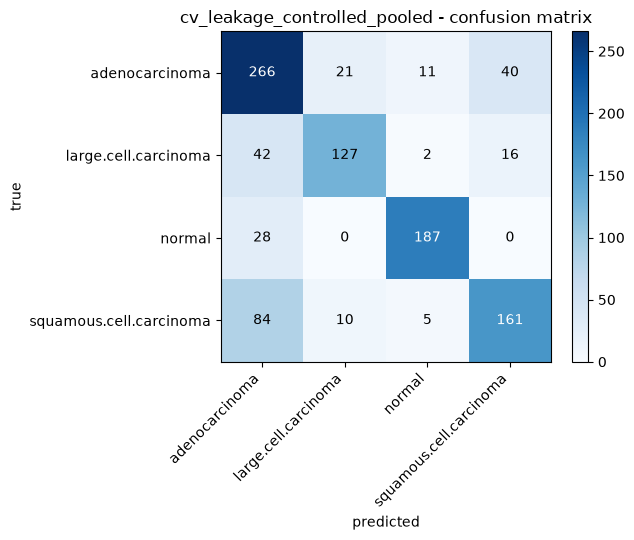

  binary_tumor_vs_healthy_accuracy: 0.954
  subtype_accuracy_all_tumors: 0.7057324840764331
  subtype_accuracy_given_detected_tumor: 0.7222946544980443
  n_tumor_samples: 785
  over_prediction_by_class: {'adenocarcinoma': 82, 'large.cell.carcinoma': -29, 'normal': -10, 'squamous.cell.carcinoma': -43}
  most_over_predicted_class: adenocarcinoma

Tumour-vs-healthy accuracy: 0.9540. Subtype accuracy among true tumour samples: 0.7057. Gap between the two tasks: 0.2483. The model separates tumour from healthy far better than it separates the three tumour subtypes, so the headline accuracy gap versus the paper is a subtype-discrimination problem, not a detection problem. 'adenocarcinoma' is the most over-predicted class and absorbs most of the subtype confusions.


In [11]:
if SPLIT_LOADED_OK and leakage_controlled_summary is not None:
    y_true_all = np.concatenate([f['y_true'] for f in valid])
    y_pred_all = np.concatenate([f['y_pred'] for f in valid])
    print(f'pooled over {len(valid)} folds, {len(y_true_all)} predictions')

    save_predictions('cv_leakage_controlled_pooled', y_true_all, y_pred_all,
                     meta={'split_variant': 'leakage_controlled_image_group',
                           'source': f'pooled over {len(valid)} leakage-controlled CV folds',
                           'purpose': 'Option B robustness check - not the headline run'})
    plot_confusion_matrix(y_true_all, y_pred_all, 'cv_leakage_controlled_pooled')

    pooled_breakdown = tumor_vs_subtype_breakdown(y_true_all, y_pred_all)
    for k, v in pooled_breakdown.items():
        print(f'  {k}: {v}')
    print()
    print(interpret_breakdown(pooled_breakdown))

## STEP 4 - direct comparison against the existing headline

Read live from `outputs/results_table.csv` (never a hardcoded number, unless that file happens to be
absent on this machine, in which case a documented fallback is used and clearly labelled as such).

In [12]:
if SPLIT_LOADED_OK and leakage_controlled_summary is not None:
    headline = load_headline_reference()
    print('EXISTING HEADLINE (read live):')
    for k, v in headline.items():
        print(f'  {k}: {v}')

    comparison = compare_to_headline(leakage_controlled_summary, headline)
    print()
    print('SIDE-BY-SIDE COMPARISON')
    print('-' * 50)
    print(f"  leakage-controlled accuracy : {comparison['leakage_controlled_accuracy_mean']:.4f} "
          f"+/- {comparison['leakage_controlled_accuracy_std']:.4f}")
    print(f"  headline accuracy           : {comparison['headline_accuracy_mean']:.4f} "
          f"+/- {comparison['headline_accuracy_std']:.4f}")
    print(f"  difference                  : {comparison['difference']:+.4f}")
    print(f"  within headline's own std?  : {comparison['within_headline_std_dev']}")
    print()
    print(comparison['verdict'])

EXISTING HEADLINE (read live):
  accuracy_mean: 0.705936
  accuracy_std: 0.119965
  f1_macro_mean: 0.708897
  binary_tumor_acc: 0.956984
  subtype_acc: 0.648504
  source: C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\outputs\results_table.csv ('MiniConvNet (3-fold CV)' row, live)

SIDE-BY-SIDE COMPARISON
--------------------------------------------------
  leakage-controlled accuracy : 0.7410 +/- 0.0424
  headline accuracy           : 0.7059 +/- 0.1200
  difference                  : +0.0351
  within headline's own std?  : True

The leakage-controlled result is WITHIN the original headline's own standard deviation - i.e. not a meaningfully different result given the noise already present in a 3-fold estimate. This is consistent with (though does not by itself prove) the original 70.59% figure being reasonably robust to the leakage found in Phase 1.


## STEP 6 - save results (new files only - `outputs/results_table.csv` is never touched)

In [13]:
if SPLIT_LOADED_OK and leakage_controlled_summary is not None:
    paths = write_leakage_controlled_cv_results(
        per_fold_df=fold_tbl, summary=leakage_controlled_summary, comparison=comparison,
        group_leakage_check=group_check,
        extra={'pooled_confusion_matrix': confusion(y_true_all, y_pred_all).tolist(),
               'pooled_breakdown': pooled_breakdown})
    print('files written:')
    for k, v in paths.items():
        print(f'  {k}: {v}')
    print()
    print('outputs/results_table.csv was NOT modified - confirm by re-reading it:')
    print(pd.read_csv(RESULTS_TABLE_CSV)[['model', 'accuracy', 'accuracy_std']].to_string(index=False))

files written:
  csv: C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\outputs\leakage\leakage_controlled_cv_results.csv
  json: C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\outputs\leakage\leakage_controlled_cv_results.json

outputs/results_table.csv was NOT modified - confirm by re-reading it:
                  model  accuracy  accuracy_std
MiniConvNet (3-fold CV)  0.705936      0.119965
               ResNet50  0.701587           NaN
                  VGG16  0.600000           NaN
       MobileNetV3Small  0.634921           NaN
       EfficientNetV2B0  0.644444           NaN


## STEP 5 - interpretation

Fill in once the cells above have actually been run. **Report the actual result regardless of
direction.** If it is lower, that is not a failure of this notebook or of MiniConvNet - it is Option
B doing exactly what it was built to do: giving a more honest estimate by removing a specific,
already-identified source of optimistic bias in the original CV methodology.

- Did the leakage-controlled result fall inside or outside the original headline's own standard
  deviation (Step 4)?
- If outside and lower: state plainly that the leakage-controlled figure should now be treated as the
  more defensible number for this dataset, and that the gap is evidence the original pooled,
  non-group-aware CV was inflated by cross-fold duplicate/near-duplicate leakage.
- If outside and higher (less likely, per the prior evidence cited in the intro): report this
  plainly too, and note that it would be an unexpected direction worth double-checking (e.g. did the
  group-aware re-partitioning happen to produce an easier class balance in the test folds by chance -
  check the per-fold class counts printed in Step 2 against the original notebook's fold class
  counts).
- If inside (within one std dev): state that this specific leakage-controlled check does not, by
  itself, invalidate the original headline - it is one piece of evidence supporting it, not proof the
  number is fully clean (patient-level leakage remains unverifiable per Phase 1's own findings, and
  the inner train/val split within each fold is still not group-aware - see the limitations below).

In [14]:
if SPLIT_LOADED_OK and leakage_controlled_summary is not None:
    print('LEAKAGE-CONTROLLED ACCURACY (mean +/- std):', end=' ')
    print(f"{comparison['leakage_controlled_accuracy_mean']:.4f} +/- "
          f"{comparison['leakage_controlled_accuracy_std']:.4f}")
    print('ORIGINAL HEADLINE ACCURACY (mean +/- std): ', end=' ')
    print(f"{comparison['headline_accuracy_mean']:.4f} +/- {comparison['headline_accuracy_std']:.4f}")
    print(f"DIFFERENCE:                                {comparison['difference']:+.4f}")
    print(f"WITHIN ORIGINAL STD DEV?:                   {comparison['within_headline_std_dev']}")
    print(f"FOLDS EXCLUDED FOR COLLAPSE:                 {leakage_controlled_summary['n_folds_excluded_collapsed']} "
          f"collapsed, {leakage_controlled_summary['n_folds_excluded_partial_collapse']} partially collapsed "
          f"(of {leakage_controlled_summary['n_folds_total']} total)")
    print('FILES CREATED:')
    print(f'  {LEAKAGE_CONTROLLED_CV_RESULTS_CSV}')
    print(f'  {LEAKAGE_CONTROLLED_CV_RESULTS_JSON}')
    print(f"  outputs/predictions/cv_leakage_controlled_fold{{1,2,3}}_predictions.csv")
    print(f'  outputs/predictions/cv_leakage_controlled_pooled_predictions.csv')
    print('CPU TIME:                                   sum of per-fold minutes printed above')
    print(f"CONCLUSION:                                  {comparison['verdict']}")
elif SPLIT_LOADED_OK and leakage_controlled_summary is None:
    print('LEAKAGE-CONTROLLED ACCURACY (mean +/- std): n/a - all folds were invalid, see above')
    print('CONCLUSION: all folds collapsed or partially collapsed - this is itself a finding to')
    print('write up with the per-fold confusion matrices, not to silently retry.')
else:
    print('Nothing to report - the leakage-controlled split could not be loaded (see STEP 1 above).')

print()
print('LIMITATIONS:')
print('  - the inner 15% train/val split within each fold is NOT group-aware (only the outer')
print('    fold/test boundary is) - a stricter version could extend group-awareness there too;')
print('  - patient-level leakage remains unverifiable (Phase 1 finding: no genuine patient IDs')
print('    exist in this dataset) - this check only bounds duplicate/near-duplicate image leakage;')
print('  - a single seed (42) and a single StratifiedGroupKFold partition were used - fold-to-fold')
print('    variance was already large in the original headline (+/-12.00%), and this evaluation')
print('    does not itself add a second independent estimate of that variance.')

LEAKAGE-CONTROLLED ACCURACY (mean +/- std): 0.7410 +/- 0.0424
ORIGINAL HEADLINE ACCURACY (mean +/- std):  0.7059 +/- 0.1200
DIFFERENCE:                                +0.0351
WITHIN ORIGINAL STD DEV?:                   True
FOLDS EXCLUDED FOR COLLAPSE:                 0 collapsed, 0 partially collapsed (of 3 total)
FILES CREATED:
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\outputs\leakage\leakage_controlled_cv_results.csv
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\outputs\leakage\leakage_controlled_cv_results.json
  outputs/predictions/cv_leakage_controlled_fold{1,2,3}_predictions.csv
  outputs/predictions/cv_leakage_controlled_pooled_predictions.csv
CPU TIME:                                   sum of per-fold minutes printed above
CONCLUSION:                                  The leakage-controlled result is WITHIN the original headline's own standard deviation - i.e. not a